In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import differential_evolution

# Import du fichier excel 

In [3]:
fichier_excel = "C:/Users/catet/Documents/exo_Autoconso_PV.xlsx"

# Liste les noms des feuilles
xls = pd.ExcelFile(fichier_excel)
print(xls.sheet_names) 

df = pd.read_excel(fichier_excel, sheet_name="demande_horaire",skiprows=4)
df.columns = ["date", "Heure", "Consommation ménage, kWh", "PV,kWc", "1","2"] 

print(df.head())
df

['a faire', 'demande_horaire', 'Indicateur']
        date     Heure  Consommation ménage, kWh  PV,kWc    1    2
0 2020-01-01  00:00:00                  0.629820     0.0  0.0  0.0
1 2020-01-01  01:00:00                  0.604557     0.0  0.0  0.0
2 2020-01-01  02:00:00                  0.601412     0.0  0.0  0.0
3 2020-01-01  03:00:00                  0.582017     0.0  0.0  0.0
4 2020-01-01  04:00:00                  0.555884     0.0  0.0  0.0


,date,Heure,"Consommation ménage, kWh","PV,kWc",1,2
0,2020-01-01,00:00:00,0.629820,0.000000,0.000000,0.00
1,2020-01-01,01:00:00,0.604557,0.000000,0.000000,0.00
2,2020-01-01,02:00:00,0.601412,0.000000,0.000000,0.00
3,2020-01-01,03:00:00,0.582017,0.000000,0.000000,0.00
4,2020-01-01,04:00:00,0.555884,0.000000,0.000000,0.00
...,...,...,...,...,...,...
8755,2020-12-31,1900-12-29 19:00:00,0.529768,0.016667,0.016667,0.05
8756,2020-12-31,1900-12-29 20:00:00,0.507532,0.000000,0.000000,0.00
8757,2020-12-31,1900-12-29 21:00:00,0.480113,0.000000,0.000000,0.00
8758,2020-12-31,1900-12-29 22:00:00,0.466189,0.000000,0.000000,0.00


In [8]:
df["Heure"] = pd.to_datetime(df["Heure"], format="%H:%M:%S", errors="coerce").dt.time
#Fusionner la colonne "Date" et "Heure"
df["Datetime"] = pd.to_datetime(df["date"].astype(str) + " " + df["Heure"].astype(str))

# Définir la colonne "Datetime" comme index
df.set_index("Datetime", inplace=True)
df

,date,Heure,"Consommation ménage, kWh","PV,kWc",1,2
Datetime,,,,,,
2020-01-01 00:00:00,2020-01-01,00:00:00,0.629820,0.000000,0.000000,0.00
2020-01-01 01:00:00,2020-01-01,01:00:00,0.604557,0.000000,0.000000,0.00
2020-01-01 02:00:00,2020-01-01,02:00:00,0.601412,0.000000,0.000000,0.00
2020-01-01 03:00:00,2020-01-01,03:00:00,0.582017,0.000000,0.000000,0.00
2020-01-01 04:00:00,2020-01-01,04:00:00,0.555884,0.000000,0.000000,0.00
...,...,...,...,...,...,...
2020-12-31 19:00:00,2020-12-31,19:00:00,0.529768,0.016667,0.016667,0.05
2020-12-31 20:00:00,2020-12-31,20:00:00,0.507532,0.000000,0.000000,0.00
2020-12-31 21:00:00,2020-12-31,21:00:00,0.480113,0.000000,0.000000,0.00


# Tableau de valeur 

In [84]:
Puissance = 8
df1 = df[["Consommation ménage, kWh", "PV,kWc"]]
df1["PV,kWc"]= Puissance * df1["PV,kWc"]
df1

C:\Users\catet\AppData\Local\Temp\ipykernel_7872\2597441046.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["PV,kWc"]= Puissance * df1["PV,kWc"]


,"Consommation ménage, kWh","PV,kWc"
Datetime,,
2020-01-01 00:00:00,0.629820,0.000000
2020-01-01 01:00:00,0.604557,0.000000
2020-01-01 02:00:00,0.601412,0.000000
2020-01-01 03:00:00,0.582017,0.000000
2020-01-01 04:00:00,0.555884,0.000000
...,...,...
2020-12-31 19:00:00,0.529768,0.133333
2020-12-31 20:00:00,0.507532,0.000000
2020-12-31 21:00:00,0.480113,0.000000


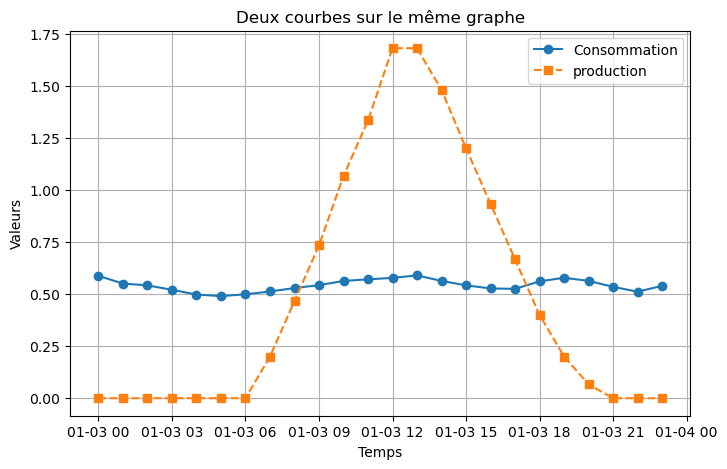

In [86]:
# Tracé des courbes
plt.figure(figsize=(8, 5))
plt.plot(df1.loc['2020-01-03'].index, df1.loc['2020-01-03', 'Consommation ménage, kWh'], 
         marker='o', linestyle='-', label='Consommation')

plt.plot(df1.loc['2020-01-03'].index, df1.loc['2020-01-03', 'PV,kWc'], 
         marker='s', linestyle='--', label='production')


# Ajout des labels et légende
plt.xlabel('Temps')
plt.ylabel('Valeurs')
plt.title('Deux courbes sur le même graphe')
plt.legend()
plt.grid(True)
plt.show()


## Autoconsommation 

In [89]:
# Créer une nouvelle colonne avec le minimum entre deux colonnes
df1["aut_c"] = np.minimum(df1["Consommation ménage, kWh"], df1["PV,kWc"])
df1['ecart'] = df1["PV,kWc"]-df1["Consommation ménage, kWh"]

C:\Users\catet\AppData\Local\Temp\ipykernel_7872\2493980230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["aut_c"] = np.minimum(df1["Consommation ménage, kWh"], df1["PV,kWc"])


,"Consommation ménage, kWh","PV,kWc",aut_c
Datetime,,,
2020-01-01 00:00:00,0.629820,0.000000,0.000000
2020-01-01 01:00:00,0.604557,0.000000,0.000000
2020-01-01 02:00:00,0.601412,0.000000,0.000000
2020-01-01 03:00:00,0.582017,0.000000,0.000000
2020-01-01 04:00:00,0.555884,0.000000,0.000000
...,...,...,...
2020-12-31 19:00:00,0.529768,0.133333,0.133333
2020-12-31 20:00:00,0.507532,0.000000,0.000000
2020-12-31 21:00:00,0.480113,0.000000,0.000000


# fonctionnement en déficit

In [99]:
import pandas as pd

# Création d'une colonne booléenne : True si écart < 0, sinon False
df1['deficit'] = df1['ecart'] < 0  

# Identifier les débuts de nouvelles périodes de déficit
df1['groupe'] = (df1['deficit'] != df1['deficit'].shift()).cumsum()
df_deficit = df1[df1['deficit']]
durees_deficit = df_deficit.groupby('groupe').size()

print(durees_deficit)


groupe
1       9
3      15
5      15
7      16
9      16
       ..
723    12
725    13
727    13
729    16
731     6
Length: 366, dtype: int64


C:\Users\catet\AppData\Local\Temp\ipykernel_7872\1842107588.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['deficit'] = df1['ecart'] < 0


In [101]:
max_deficit = durees_deficit.max()
sum_deficit = durees_deficit.sum()
print(f"Le déficit le plus long a duré {max_deficit} heures.")
print(f"Le déficit total est de {sum_deficit} heures.")

Le déficit le plus long a duré 19 heures.
Le déficit total est de 4886 heures.


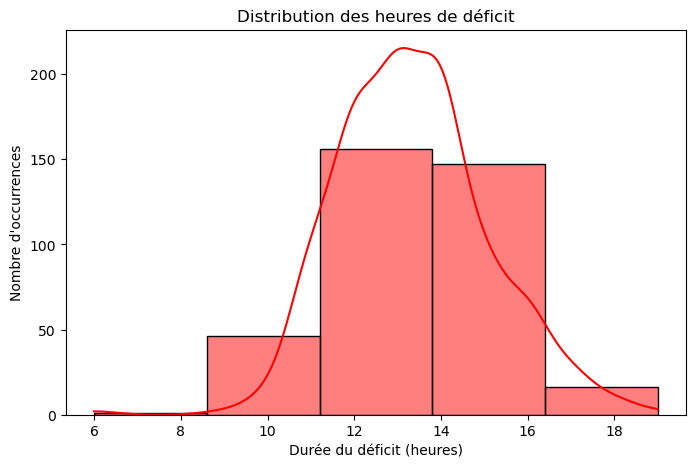

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(durees_deficit, bins=5, kde=True, color="red")
plt.xlabel("Durée du déficit (heures)")
plt.ylabel("Nombre d'occurrences")
plt.title("Distribution des heures de déficit")
plt.show()


# Calcul du LCOE de l'installation 

In [30]:
capacity_factor = 0.1215 # nb_prod_tot/(Puissance*8760)
power_capacity = 20 #kW
fixed_O_M = 50  #($/kW/an)
overnight_cost = 2830 #($/kW)
interest_rate = 0.0001 #(%)
mortgage_period = 20 # ans
degradation_rate = 0.005

In [32]:
def LCOE(power_capacity, capacity_factor, fixed_O_M, overnight_cost, interest_rate, mortgage_period):
    
    # Convertir le taux d'intérêt en décimal
    r = interest_rate / 100  

    # Production annuelle d'électricité (MWh/an)
    energy_per_year = power_capacity * capacity_factor * 8760 / 1000  

    # Coût d'investissement annualisé (CAPEX annualisé)
    CRF = (r * (1 + r) ** mortgage_period) / ((1 + r) ** mortgage_period - 1)
    annualized_CAPEX = overnight_cost * power_capacity * CRF  

    annual_O_M = fixed_O_M * power_capacity  

    # Calcul du LCOE
    LCOE = (annualized_CAPEX + annual_O_M) / energy_per_year 

    return LCOE




In [34]:
LCOE_c = LCOE(power_capacity, capacity_factor, fixed_O_M, overnight_cost, interest_rate, mortgage_period)
print(f"LCOE = {LCOE_c:.2f} $/MWh")

LCOE = 179.93 $/MWh


## Avec actualisation du facteur de charge 

In [38]:
def LCOE_d(power_capacity, capacity_factor, fixed_O_M, overnight_cost, interest_rate, mortgage_period, degradation_rate):  

    
    # Convertir le taux d'intérêt en décimal
    r = interest_rate / 100  

    # Capital Recovery Factor (CRF) pour annualiser le CAPEX
    CRF = (r * (1 + r) ** mortgage_period) / ((1 + r) ** mortgage_period - 1)

    # Coût d'investissement annualisé (CAPEX annualisé)
    annualized_CAPEX = overnight_cost * power_capacity * CRF  

    # Coûts O&M annuels (fixe)
    annual_O_M = fixed_O_M * power_capacity  

    # Calcul du LCOE avec facteur de charge décroissant
    total_discounted_cost = 0
    total_discounted_energy = 0

    for t in range(1, mortgage_period + 1):
        # Facteur de charge actualisé en tenant compte de la dégradation
        capacity_factor_t = capacity_factor * (1 - degradation_rate) ** (t - 1)
        
        # Production annuelle d'électricité (MWh) pour l'année t
        energy_t = power_capacity * capacity_factor_t * 8760 / 1000  
        
        # Actualisation des coûts et de la production
        discounted_cost = (annualized_CAPEX + annual_O_M) / (1 + r) ** t
        discounted_energy = energy_t / (1 + r) ** t

        # Accumulation
        total_discounted_cost += discounted_cost
        total_discounted_energy += discounted_energy

    # Calcul final du LCOE
    LCOE_value = total_discounted_cost / total_discounted_energy  

    return LCOE_value


In [40]:
LCOE_d = LCOE_d(power_capacity, capacity_factor, fixed_O_M, overnight_cost, interest_rate, mortgage_period,degradation_rate)
print(f"LCOE = {LCOE_d:.2f} $/MWh")

LCOE = 188.62 $/MWh


# Optimisation de l'installation 

In [198]:
aut =[]
aut_2 = []
cout = []
TVE = 200


#Emission en fonction de la puissance:
GES = [i for i in range(1,21)] # on multiplie la puissance par 1 kgCO2e/MWh


# durée des déficits
max_d =[]
long_d =[]
for i in range(1,21):
    dfc = df[["Consommation ménage, kWh", "PV,kWc"]]
    dfc["PV,kWc"]= i * dfc["PV,kWc"]
    dfc['ecart'] = dfc["PV,kWc"]-dfc["Consommation ménage, kWh"]
    dfc['deficit'] = dfc['ecart'] < 0  
    # Identifier les débuts de nouvelles périodes de déficit
    dfc['groupe'] = (dfc['deficit'] != dfc['deficit'].shift()).cumsum()
    # Filtrer uniquement les périodes où il y a un déficit
    df_deficit = dfc[dfc['deficit']]
    # Regrouper par période et compter la durée de chaque période
    durees_deficit = df_deficit.groupby('groupe').size()
    max_d.append(durees_deficit.max())
    long_d.append(durees_deficit.sum())
    

# Rentabilité 
aut =[]
aut_2 = []
cout = []
TVE = 200
for i in range (1,21):
    puissance = i

    #definition de df1 pour chaque puissance 
    dfr = df[["Consommation ménage, kWh", "PV,kWc"]]
    dfr["PV,kWc"]= puissance * dfr["PV,kWc"]
    dfr["aut_c"] = np.minimum(dfr["Consommation ménage, kWh"], dfr["PV,kWc"]) 
    dfr["rentabilité"] = (TVE * (dfr["Consommation ménage, kWh"]-dfr["aut_c"]) + (LCOE_d - TVE) * dfr["aut_c"])/1000 # on obtient le coout de la consommation €/kWh.

    #definition des varibales d'interet
    nb_prod_tot = dfr['PV,kWc'].sum()
    nb_aut_tot = dfr['aut_c'].sum()
    nb_tot = dfr['Consommation ménage, kWh'].sum()
    cout_tot = dfr["rentabilité"].sum()

    #aggregation dans la liste 
    aut.append(100 * nb_aut_tot/nb_prod_tot)
    aut_2.append(100 * nb_aut_tot/nb_tot)
    cout.append(1000 * cout_tot/(nb_tot))



C:\Users\catet\AppData\Local\Temp\ipykernel_7872\373422802.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc["PV,kWc"]= i * dfc["PV,kWc"]
C:\Users\catet\AppData\Local\Temp\ipykernel_7872\373422802.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfc['ecart'] = dfc["PV,kWc"]-dfc["Consommation ménage, kWh"]
C:\Users\catet\AppData\Local\Temp\ipykernel_7872\373422802.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

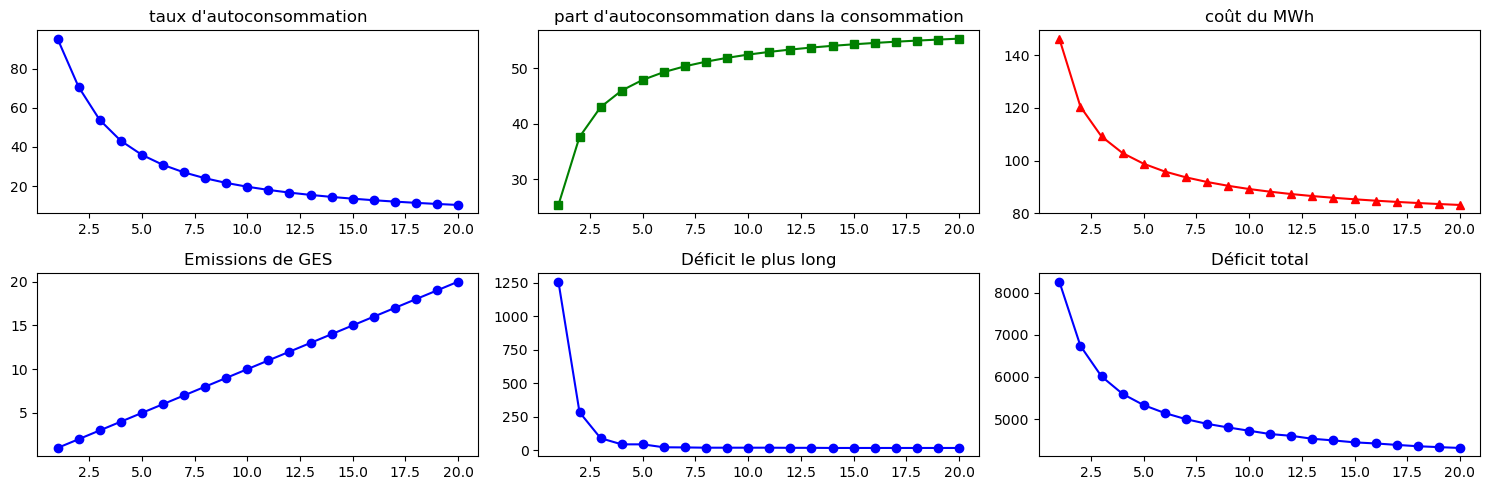

In [200]:

# Données d'exemple
x = [i for i in range(1,21)]

# Création des sous-graphiques (2 ligne, 3 colonnes)
fig, axes = plt.subplots(2, 3, figsize=(15, 5))

axes = axes.flatten()

# Premier graphe
axes[0].plot(x,aut , marker='o', color='b')
axes[0].set_title("taux d'autoconsommation")

# Deuxième graphe
axes[1].plot(x, aut_2, marker='s', color='g')
axes[1].set_title("part d'autoconsommation dans la consommation")

# Troisième graphe
axes[2].plot(x, cout, marker='^', color='r')
axes[2].set_title("coût du MWh")

axes[3].plot(x,GES , marker='o', color='b')
axes[3].set_title("Emissions de GES")

axes[4].plot(x,max_d , marker='o', color='b')
axes[4].set_title("Déficit le plus long")

axes[5].plot(x,long_d , marker='o', color='b')
axes[5].set_title("Déficit total")


# Affichage des graphiques
plt.tight_layout()
plt.show()


### Normalisation des valeurs 

In [202]:
def score(a,b,c,d): 
    but = []
#  Définir les bornes min-max pour normaliser
    aut_min, aut_max = 10, 100  
    aut_2_min, aut_2_max = 25, 60  
    cout_min, cout_max = 70, 150 
    GES_min, GES_max = 1, 20
    max_d_min, max_d_max = 0, 8760
    long_d_min, long_d_max = 0, 1500

    #  Normalisation des critères
    aut_norm = 0
    aut_2_norm = 0
    cout_norm = 0
    GES_n = 0
    max_dn =0
    long_dn =0
    for i in range (0,20): 
        aut_norm = (aut[i] - aut_min) / (aut_max - aut_min)
        aut_2_norm = (aut_2[i] - aut_2_min) / (aut_2_max - aut_2_min)
        cout_norm = (cout[i] - cout_min) / (cout_max - cout_min)
        GES_n = (GES[i] - GES_min) / (GES_max - GES_min)
        max_dn = (max_d[i] - max_d_min) / (max_d_max - max_d_min)
        long_dn = (long_d[i] - long_d_min) / (long_d_max - long_d_min)
        but.append( a*cout_norm + b*GES_n + c*max_dn + d*long_dn)
    return but

      
        

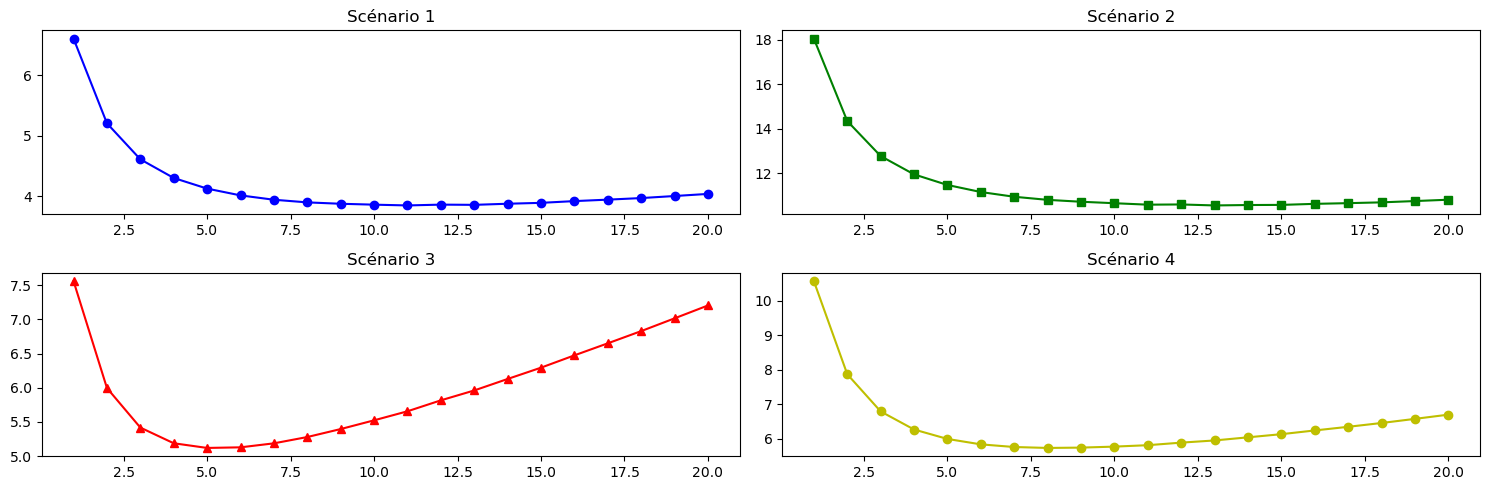

In [206]:


# Création des sous-graphiques (2 ligne, 3 colonnes)
fig, axes = plt.subplots(2, 2, figsize=(15, 5))

axes = axes.flatten()

# Premier graphe
axes[0].plot(x, score(1,1,1,1), marker='o', color='b')
axes[0].set_title("Scénario 1")

# Deuxième graphe
axes[1].plot(x, score(1,2,4,3), marker='s', color='g')
axes[1].set_title("Scénario 2")

# Troisième graphe
axes[2].plot(x, score(2,4,1,1), marker='^', color='r')
axes[2].set_title("Scénario 3")

axes[3].plot(x,score(5,3,2,1) , marker='o', color='y')
axes[3].set_title("Scénario 4")


# Affichage des graphiques
plt.tight_layout()
plt.show()
